# RIDNet Denoising

### Project Constraints & Resources

* **Experimentation Source:** [Image Denoising using Deep Learning (Medium)](https://medium.com/analytics-vidhya/image-denoising-using-deep-learning-dc2b19a3fd54)
* **Input Handling:** **Un-Normalized Inputs** (per specific instructions).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('dark_background')
print("Pytorch version :",torch.__version__)
print("Numpy version :",np.__version__)
print("Using device : ",device)

Pytorch version : 2.7.0+cu126
Numpy version : 2.3.4
Using device :  cuda


2026/01/04 15:58:47 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/01/04 15:58:47 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026-01-04 15:58:47.088 | INFO     | __main__:<module>:13 - MLflow run started | experiment=AnalyticsVidhya | run_name=1-pridnet


In [3]:
# Paths
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
BASE_DIR = NOTEBOOK_DIR.parents[2]
DATASET_DIR = BASE_DIR / "data" / "1-all-noise-no-cf"

MODEL_OUTPUT_DIR = BASE_DIR / "models" / NOTEBOOK_DIR.parents[0].name / NOTEBOOK_DIR.name
MODEL_OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

INPUT_DIR  = DATASET_DIR / "input"
TARGET_DIR = DATASET_DIR / "target"
HEIGHT , WIDTH = 256 , 256
IMAGE_SIZE = (HEIGHT , WIDTH)
import sys
sys.path.append(str(BASE_DIR))
import helper

for name, directory in [("Input", INPUT_DIR), ("Target", TARGET_DIR)]:
    if directory.is_dir():
        files = list(directory.glob('*'))
        print(f"✅ {name} Directory: {'Contains ' + str(len(files)) + ' files.' if files else 'Empty.'}")
    else:
        print(f"❌ {name} Directory NOT found at: {directory}")

✅ Input Directory: Contains 20000 files.
✅ Target Directory: Contains 20000 files.


In [ ]:
mlflow_enabled = True
if mlflow_enabled:
    from loguru import logger
    import mlflow
    mlflow.end_run()
    mlflow.pytorch.autolog()
    run_name = NOTEBOOK_DIR.name
    experiment_name =  "AnalyticsVidhya"
    tracking_uri =  "http://localhost:5000"
    mlflow.set_tracking_uri(tracking_uri)
    mlflow.set_experiment(experiment_name)
    mlflow.start_run(run_name=run_name,log_system_metrics=True)
    logger.info(f"MLflow run started | experiment={experiment_name} | run_name={run_name}")

In [4]:
class InterferogramDataset(Dataset):
    """Simple segmentation dataset for image-mask pairs"""
    
    def __init__(self, image_dir, mask_dir, transform=None, img_size=(512,512)):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.img_size = img_size
        
        # Get all image files
        valid_exts = {".jpg", ".jpeg", ".png"}
        self.images = sorted([f for f in self.image_dir.iterdir() if f.suffix.lower() in valid_exts])
        self.masks = sorted([f for f in self.mask_dir.iterdir() if f.suffix.lower() in valid_exts])
        
        assert len(self.images) == len(self.masks), "Images and masks count mismatch!"
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image and mask
        img = Image.open(self.images[idx]).convert('L')
        mask = Image.open(self.masks[idx]).convert('L')  # Grayscale
        
        # Resize
        img = img.resize(self.img_size, Image.NEAREST)
        mask = mask.resize(self.img_size, Image.NEAREST)
        
        # Convert to numpy - UNNORMALISED
        img = np.array(img).astype(np.float32) /255
        mask = np.array(mask).astype(np.float32) /255
        
        # To tensor (C, H, W)
        img = torch.from_numpy(img).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)  # Add channel dim
        
        return img, mask

In [5]:
# Create datasets
train_dataset = InterferogramDataset(INPUT_DIR, TARGET_DIR, img_size=IMAGE_SIZE)
BATCH_SIZE = 16
# Split into train/val (80/20)
train_size = int(0.5 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")


Train samples: 10000, Val samples: 10000


In [6]:
class EAM(nn.Module):
    def __init__(self, channels):
        super().__init__()

        # ---- Dilated parallel convolutions ----
        self.dilated_1 = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, dilation=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=2, dilation=2),
            nn.ReLU(inplace=True),
        )

        self.dilated_2 = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=3, dilation=3),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=4, dilation=4),
            nn.ReLU(inplace=True),
        )

        self.merge = nn.Conv2d(channels * 2, channels, 3, padding=1)

        # ---- Residual block ----
        self.res1 = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
        )

        # ---- Enhanced residual block ----
        self.res2 = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 1),
        )

        # ---- Feature Attention ----
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # Parallel dilated paths
        p1 = self.dilated_1(x)
        p2 = self.dilated_2(x)

        merged = self.merge(torch.cat([p1, p2], dim=1))
        x1 = x + merged

        # Residual learning
        r1 = self.res1(x1)
        x2 = F.relu(x1 + r1)

        r2 = self.res2(x2)
        x3 = F.relu(x2 + r2)

        # Attention
        attn = self.attention(x3)
        out = x + x3 * attn   # residual-on-residual

        return out

class RIDNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_filters=2, num_eams=4):
        super().__init__()

        self.entry = nn.Conv2d(in_channels, base_filters, 3, padding=1)

        self.eams = nn.Sequential(
            *[EAM(base_filters) for _ in range(num_eams)]
        )

        self.exit = nn.Conv2d(base_filters, out_channels, 3, padding=1)

    def forward(self, x):
        feat = self.entry(x)
        feat = self.eams(feat)
        out = self.exit(feat)
        return out + x  # global residual


In [ ]:
model = RIDNet(in_channels=1, out_channels=1, base_filters=6).to(device)
x = torch.randn(1, 1, 256, 256).to(device)
y = model(x)
print(y.shape)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
helper.inspect_model(
    model, 
    input_size=(1,1,HEIGHT,WIDTH),
    criterion=criterion,
    optimizer=optimizer,
    model_name="U-Net-Lite with Residual Connections"
)

torch.Size([1, 1, 256, 256])


────────────────────────────────────── U-Net-Lite with Residual Connections ───────────────────────────────────────

Architecture Summary:

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
RIDNet                                        [1, 1, 256, 256]          [1, 1, 256, 256]          --
├─Conv2d: 1-1                                 [1, 1, 256, 256]          [1, 6, 256, 256]          60
├─Sequential: 1-2                             [1, 6, 256, 256]          [1, 6, 256, 256]          --
│    └─EAM: 2-1                               [1, 6, 256, 256]          [1, 6, 256, 256]          --
│    │    └─Sequential: 3-1                   [1, 6, 256, 256]          [1, 6, 256, 256]          660
│    │    └─Sequential: 3-2                   [1, 6, 256, 256]          [1, 6, 256, 256]          660
│    │    └─Conv2d: 3-3                       [1, 12, 256, 256]         [1, 6, 256, 256]          654
│    │    └─Sequential: 3-4                   [1, 6, 256, 256]          [1, 6, 256, 256]          660
│    │    └─Sequential: 3-5                   [1, 6, 256, 256]          [1, 6, 256

MACs and Parameters (ptflops):

╷              
  Metric               │       Value  
 ══════════════════════╪═════════════ 
  Total Parameters     │      16,099  
  Trainable Parameters │      16,099  
  Optimizer Params     │      16,099  
  Model Size (MB)      │       0.061  
  MACs                 │ 910.36 MMac  
  FLOPs (approx)       │ 910.36 MMac  
  Loss Function        │     MSELoss  
  Optimizer            │        Adam  
                       ╵

{'total_params': 16099,
 'trainable_params': 16099,
 'optimizer_params': 16099,
 'model_size_mb': 0.061412811279296875,
 'MACs': '910.36 MMac',
 'FLOPs': '910.36 MMac',
 'criterion': 'MSELoss',
 'optimizer': 'Adam'}

In [12]:
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    psnr_metric.reset()
    ssim_metric.reset()

    for imgs, masks in tqdm(loader, desc="Training", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        # Metrics (detach gradients)
        psnr_metric.update(outputs.detach(), masks)
        ssim_metric.update(outputs.detach(), masks)
    n = len(loader)
    avg_loss = total_loss / n
    avg_psnr = psnr_metric.compute().item()
    avg_ssim = ssim_metric.compute().item()
    return avg_loss, avg_psnr, avg_ssim

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    psnr_metric.reset()
    ssim_metric.reset()

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Validation", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            psnr_metric.update(outputs, masks)
            ssim_metric.update(outputs, masks)
    n = len(loader)
    avg_loss = total_loss / n
    avg_psnr = psnr_metric.compute().item()
    avg_ssim = ssim_metric.compute().item()
    return avg_loss, avg_psnr, avg_ssim


In [13]:
history = {
    'train_loss': [] , 'val_loss': []
}
best_val_loss = float('inf')
print("Models will be saved at :",MODEL_OUTPUT_DIR)

Models will be saved at : C:\Users\SriRam.A\Documents\sr_proj\Hologram\models\3-analytics-vidya\4-RIDNet


In [14]:
# Training with detailed loss tracking
epochs = 25

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")

    train_loss, train_psnr, train_ssim = train_epoch(model, train_loader,criterion, optimizer, device)
    val_loss, val_psnr, val_ssim  = validate(model, val_loader ,criterion, device)
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    scheduler.step(val_loss)
    print(f"Train | Loss: {train_loss:.4f}, PSNR: {train_psnr:.2f}, SSIM: {train_ssim:.4f}")
    print(f"Val   | Loss: {val_loss:.4f}, PSNR: {val_psnr:.2f}, SSIM: {val_ssim:.4f}")
    # print(f"Loss : {'Train':<3} = {train_loss:.4f} | {'Val':<3} = {val_loss:.4f}")
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_OUTPUT_DIR /  f"best_model.pth")
        print(f" Best model saved at epoch {epoch}")

Epoch 1/25


Train | Loss: 0.0708, PSNR: 11.50, SSIM: 0.2978
Val   | Loss: 0.0134, PSNR: 18.72, SSIM: 0.5174
 Best model saved at epoch 0
Epoch 2/25


Train | Loss: 0.0101, PSNR: 19.94, SSIM: 0.5894
Val   | Loss: 0.0084, PSNR: 20.75, SSIM: 0.6409
 Best model saved at epoch 1
Epoch 3/25


Train | Loss: 0.0072, PSNR: 21.45, SSIM: 0.6646
Val   | Loss: 0.0063, PSNR: 22.03, SSIM: 0.6773
 Best model saved at epoch 2
Epoch 4/25


Train | Loss: 0.0053, PSNR: 22.72, SSIM: 0.6935
Val   | Loss: 0.0048, PSNR: 23.22, SSIM: 0.7019
 Best model saved at epoch 3
Epoch 5/25


...

Train | Loss: 0.0018, PSNR: 27.48, SSIM: 0.8519
Val   | Loss: 0.0017, PSNR: 27.61, SSIM: 0.8430
 Best model saved at epoch 20
Epoch 22/25


Train | Loss: 0.0017, PSNR: 27.63, SSIM: 0.8546
Val   | Loss: 0.0018, PSNR: 27.42, SSIM: 0.8468
Epoch 23/25


Train | Loss: 0.0018, PSNR: 27.57, SSIM: 0.8555
Val   | Loss: 0.0017, PSNR: 27.67, SSIM: 0.8602
 Best model saved at epoch 22
Epoch 24/25


Train | Loss: 0.0017, PSNR: 27.76, SSIM: 0.8582
Val   | Loss: 0.0017, PSNR: 27.75, SSIM: 0.8614
 Best model saved at epoch 23
Epoch 25/25


Train | Loss: 0.0017, PSNR: 27.72, SSIM: 0.8591
Val   | Loss: 0.0017, PSNR: 27.82, SSIM: 0.8623
 Best model saved at epoch 24


In [15]:
print("TRAINING SUMMARY")
print(f"Best Validation Loss:      {min(history['val_loss']):.4f} (Epoch {np.argmin(history['val_loss'])+1})")

TRAINING SUMMARY
Best Validation Loss:      0.0017 (Epoch 25)


In [16]:
# Save final model in multiple formats
torch.save(model.state_dict(), MODEL_OUTPUT_DIR / "final_model_state_dict.pth")
torch.save(model, MODEL_OUTPUT_DIR / "final_model_complete.pth")
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history
}, MODEL_OUTPUT_DIR / "checkpoint.pth")
print("\n✓ All models saved!")


✓ All models saved!


In [17]:
i=0

Prediction time: 16.70 ms
Input image : C:\Users\SriRam.A\Documents\sr_proj\Hologram\data\1-all-noise-no-cf\input\SNR_28dB_noisy_113.png
 Target path : C:\Users\SriRam.A\Documents\sr_proj\Hologram\data\1-all-noise-no-cf\target\SNR_28dB_clean_113.png

Evaluation Metrics
| Metric    |   Original |   Predicted |
|-----------|------------|-------------|
| PSNR (dB) |    32.56   |     41.67   |
| SSIM      |     0.7031 |      0.9485 |



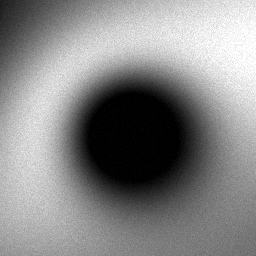
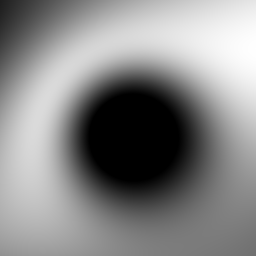
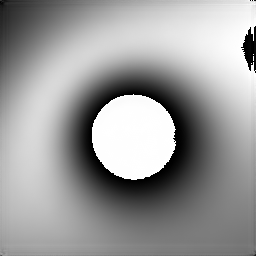

In [31]:
import time
from tabulate import tabulate

# Load best model
model.load_state_dict(torch.load(MODEL_OUTPUT_DIR / "best_model.pth", map_location=device))
model.eval()

# Get random images
input_path, target_path = helper.get_images_from_dirs([INPUT_DIR, TARGET_DIR])

# Load and preprocess
img_pil = Image.open(input_path).convert('L')
mask_pil = Image.open(target_path).convert('L')

img_resized = img_pil.resize((HEIGHT, WIDTH))
mask_resized = mask_pil.resize((HEIGHT, WIDTH))

# To tensor [0,1], shape (1,1,H,W)
img_tensor = torch.from_numpy(np.array(img_resized).astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(device)
target_tensor = torch.from_numpy(np.array(mask_resized).astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(device)

# Prediction + timing
torch.cuda.synchronize() if device.type == "cuda" else None
start_time = time.time()
with torch.no_grad():
    pred_tensor = model(img_tensor)
torch.cuda.synchronize() if device.type == "cuda" else None
elapsed_time = time.time() - start_time
print(f"Prediction time: {elapsed_time * 1000:.2f} ms")

# Metrics
psnr_original = psnr_metric(img_tensor, target_tensor)
psnr_predicted = psnr_metric(pred_tensor, target_tensor)

ssim_original = ssim_metric(img_tensor, target_tensor)
ssim_predicted = ssim_metric(pred_tensor, target_tensor)

headers = ["Metric", "Original", "Predicted"]
table_data = [
    ["PSNR (dB)", f"{psnr_original.item():.2f}", f"{psnr_predicted.item():.2f}"],
    ["SSIM",      f"{ssim_original.item():.4f}", f"{ssim_predicted.item():.4f}"],
]
print(f"Input image : {input_path}\n Target path : {target_path}")
print("\nEvaluation Metrics")
print(tabulate(table_data, headers=headers, tablefmt="github"))

# Prepare for visualization
pred = pred_tensor.squeeze().cpu().numpy()
img_np = np.array(img_resized)
mask_np = np.array(mask_resized)

helper.show_grid({
    f'Noise Mask': (img_np * 1).astype(np.uint8),
    f'Target Mask': (mask_np * 1).astype(np.uint8),
    f'Predicted Mask': (pred * 255).astype(np.uint8),
}, grid="row", width=1200)


In [32]:
from pathlib import Path
import cv2
artifact_dir = Path("mlflow_artifacts")
artifact_dir.mkdir(exist_ok=True)
i+=1
comparison = np.concatenate(
    [
        (img_np * 255).astype(np.uint8),
        (mask_np * 255).astype(np.uint8),
        (pred * 255).astype(np.uint8),
    ],
    axis=1
)

comparison_path = artifact_dir / f"{i}_comparison.png"
cv2.imwrite(str(comparison_path), comparison)
mlflow.log_artifact(str(comparison_path), artifact_path="predictions")

In [33]:
mlflow.end_run()

2026/01/04 20:05:32 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/01/04 20:05:32 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run 1-pridnet at: http://localhost:5000/#/experiments/224237832703972600/runs/23adec2fcfb04ae8b25226bb729a2ba1
🧪 View experiment at: http://localhost:5000/#/experiments/224237832703972600
